# CV Floor Results — read back from W&B

Bidirectional results exploration: pull a finished CV group from W&B and report it. Swap `GROUP`
to inspect any experiment. Independent of `bag_of_cells` (which trains/submits); this only *reads*.

In [ ]:
import pandas as pd

from sp_ml.eval import fetch_runs, panel

pd.set_option("display.width", 160)

GROUP = "floor-schurch-clr_dii-5fold"   # single 5-fold (1 repeat) floor: identity·none·mean·logreg
df = fetch_runs(group=GROUP).sort_values("cfg.cv.fold").reset_index(drop=True)
print(f"{len(df)} runs in group: {GROUP}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /cv/home/ratzana/.netrc.


5 runs in group: floor-schurch-clr_dii-5fold


## Experiment provenance — what produced these numbers

In [ ]:
r0 = df.iloc[0]
short = lambda c: str(r0[c]).split(".")[-1]
print("dataset :", r0["cfg.data.name"], "| task:", r0["cfg.task.name"])
print("model   :", " → ".join(short(f"cfg.model.{s}._target_")
                              for s in ["encoder", "graph", "pool", "readout"]))
print("CV      : n_folds=%s n_repeats=%s  (runs=%d)" %
      (r0["cfg.cv.n_folds"], r0["cfg.cv.n_repeats"], len(df)))
print("train   : epochs=%s lr=%s class_weighted=%s seed=%s" %
      (r0["cfg.train.trainer.max_epochs"], r0["cfg.train.optimizer.lr"],
       r0["cfg.train.class_weighted"], r0["cfg.seed"]))

dataset : schurch | task: clr_dii
model   : Identity → NoGraph → MeanPool → LogReg
CV      : n_folds=5 n_repeats=10  (runs=5)
train   : epochs=300 lr=0.005 class_weighted=True seed=0


## Headline — patient-level test metrics, mean ± std over folds

In [ ]:
print(panel(df)[["metric", "summary", "n"]].to_string(index=False))

    metric       summary  n
test/auroc 0.850 ± 0.070  5
test/auprc 0.885 ± 0.053  5
 test/bacc 0.717 ± 0.148  5
   test/f1 0.703 ± 0.150  5


## Per-fold breakdown (spread, best/worst)

In [ ]:
TEST = ["test/auroc", "test/auprc", "test/bacc", "test/f1"]
per = (df[["cfg.cv.fold"] + TEST]
       .rename(columns=lambda c: c.replace("cfg.cv.", "").replace("test/", "")))
print(per.to_string(index=False))
print("\nrange (max−min):", {m.replace("test/", ""): round(float(df[m].max() - df[m].min()), 3) for m in TEST})

 fold    auroc    auprc     bacc       f1
    0 0.833333 0.877083 0.583333 0.571429
    1 0.833333 0.877083 0.833333 0.844444
    2 0.916667 0.933333 0.875000 0.857143
    3 0.750000 0.804861 0.541667 0.533333
    4 0.916667 0.933333 0.750000 0.708333

range (max−min): {'auroc': 0.167, 'auprc': 0.128, 'bacc': 0.333, 'f1': 0.324}


## Val vs test (generalization sanity — selection/checkpoint was on `val/auroc`)

In [ ]:
for split in ["val", "test"]:
    ms = [f"{split}/{m}" for m in ["auroc", "auprc", "bacc", "f1"]]
    print("%-4s" % split, {m.split("/")[1]: f"{df[m].mean():.3f}±{df[m].std():.3f}" for m in ms})

val  {'auroc': '0.833±0.156', 'auprc': '0.867±0.126', 'bacc': '0.717±0.123', 'f1': '0.691±0.117'}
test {'auroc': '0.850±0.070', 'auprc': '0.885±0.053', 'bacc': '0.717±0.148', 'f1': '0.703±0.150'}


## Drill-down links

In [ ]:
ENTITY = "alexander-ratzan-new-york-university"
for _, r in df.iterrows():
    print(f"  fold {int(r['cfg.cv.fold'])}: https://wandb.ai/{ENTITY}/sp-ml/runs/{r['run_id']}")

  fold 0: https://wandb.ai/alexander-ratzan-new-york-university/sp-ml/runs/0uscwlhf
  fold 1: https://wandb.ai/alexander-ratzan-new-york-university/sp-ml/runs/udgakhdu
  fold 2: https://wandb.ai/alexander-ratzan-new-york-university/sp-ml/runs/vfb8zpfr
  fold 3: https://wandb.ai/alexander-ratzan-new-york-university/sp-ml/runs/feg8r86l
  fold 4: https://wandb.ai/alexander-ratzan-new-york-university/sp-ml/runs/pq21qact


## Pooled out-of-fold predictions — confusion / ROC / PR / calibration
One repeat → each patient is tested exactly once, so pooling the 5 folds = 35 out-of-fold
predictions (one per patient). Descriptive companion to the per-fold mean±std above: read the
confusion as row-normalized recall; AUROC/AUPRC (rank-based) are the discrimination evidence.

wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


out-of-fold predictions: (35, 7) | patients: 35


              precision    recall  f1-score   support

         CLR       0.71      0.71      0.71        17
         DII       0.72      0.72      0.72        18

    accuracy                           0.71        35
   macro avg       0.71      0.71      0.71        35
weighted avg       0.71      0.71      0.71        35



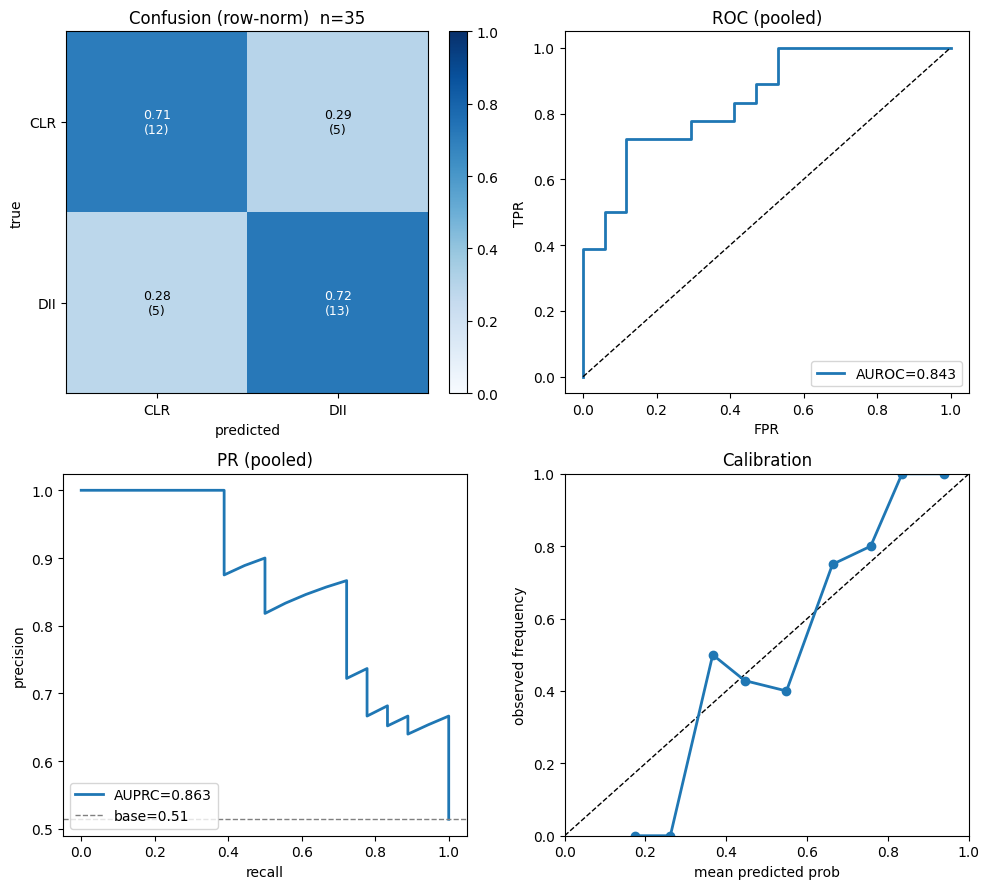

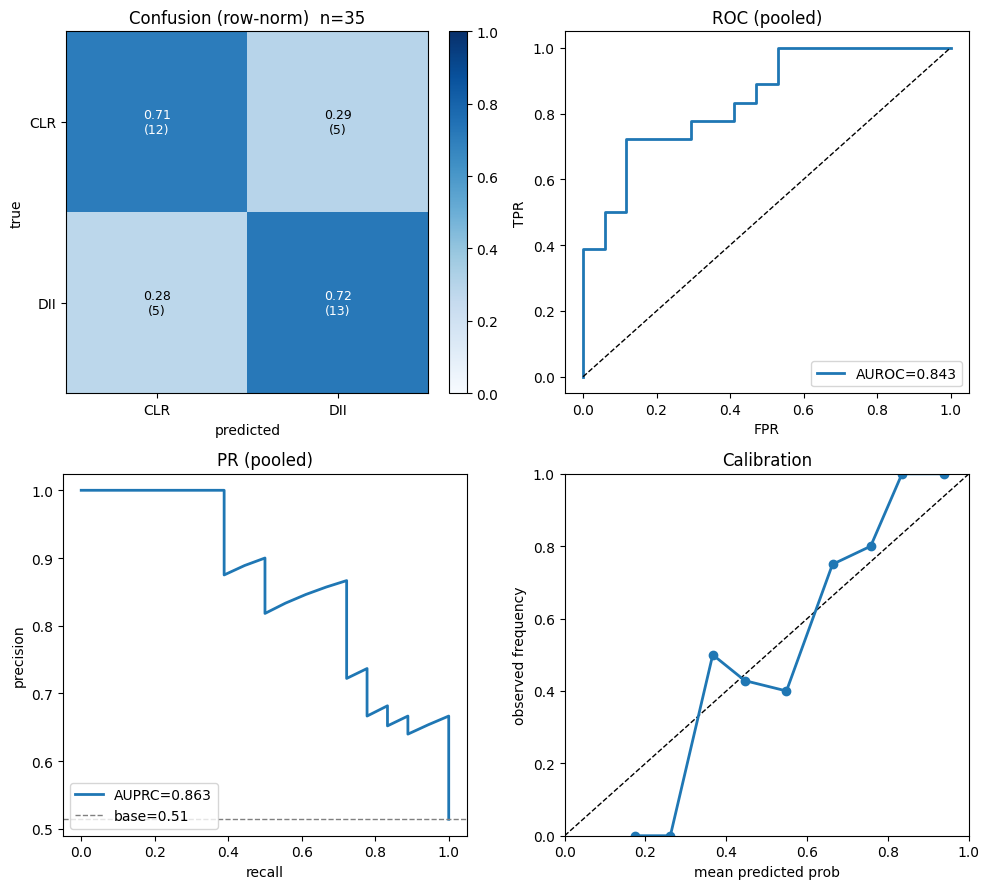

In [7]:
from sp_ml.eval import fetch_predictions, prediction_panels, report

CLASSES = list(df["cfg.task.classes"].iloc[0])
sf_preds = fetch_predictions(group=GROUP)
print("out-of-fold predictions:", sf_preds.shape, "| patients:", sf_preds["patient"].nunique())
print(report(sf_preds, class_names=CLASSES))
prediction_panels(sf_preds, class_names=CLASSES)

# Full nested CV (5 folds × 10 repeats) — stable floor

The single 5-fold run above is high-variance at 35 patients (AUROC range ~0.25). The full
Repeated Nested Stratified Group K-Fold (50 runs) averages that into a stable mean±std and gives
enough pooled patient-level predictions for honest confusion / ROC / PR / calibration.

In [8]:
NESTED_GROUP = "floor-schurch-clr_dii-5x10"   # explicit group for the nested experiment
ndf = fetch_runs(group=NESTED_GROUP)
print(f"{len(ndf)} runs (expect 50) | repeats: {sorted(ndf['cfg.cv.repeat'].unique())}")
CLASSES = list(ndf["cfg.task.classes"].iloc[0]) if len(ndf) else ["CLR", "DII"]

50 runs (expect 50) | repeats: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### Headline — two estimators, clearly labeled
**`repeat_mean` is the number to report**: mean ± std over the 10 per-repeat means (each a full
5-fold partition) → the stable estimate. `pooled` is mean ± std over all 50 individual fold-runs;
its std is *per-fold dispersion* (few patients/fold), not the uncertainty of the estimate.

In [9]:
from sp_ml.eval import repeated_cv_panel

print(repeated_cv_panel(ndf).to_string(index=False))

    metric repeat_mean  (mean±std, n=10 repeats) ← report pooled  (mean±std, n=50 runs)
test/auroc                                  0.843 ± 0.041                 0.843 ± 0.154
test/auprc                                  0.878 ± 0.031                 0.878 ± 0.118
 test/bacc                                  0.724 ± 0.041                 0.724 ± 0.146
   test/f1                                  0.708 ± 0.043                 0.708 ± 0.154


### Per-repeat stability (mean over each repeat's 5 folds)

In [10]:
print(panel(ndf, by="cfg.cv.repeat")
      .pivot(index="cfg.cv.repeat", columns="metric", values="mean").round(3).to_string())

metric         test/auprc  test/auroc  test/bacc  test/f1
cfg.cv.repeat                                            
0                   0.885       0.850      0.717    0.703
1                   0.920       0.900      0.650    0.627
2                   0.885       0.850      0.692    0.676
3                   0.894       0.867      0.758    0.738
4                   0.923       0.900      0.783    0.761
5                   0.834       0.783      0.692    0.672
6                   0.872       0.833      0.767    0.754
7                   0.883       0.850      0.733    0.720
8                   0.837       0.783      0.708    0.689
9                   0.853       0.817      0.742    0.739


### Patient-level predictions — confusion / ROC / PR / calibration
350 test predictions (35 patients × 10 repeats) averaged per patient → one row/patient (honest
N=35). `prediction_panels(..., mode="pooled")` would instead use all 350.

wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


...

wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


wandb:   1 of 1 files downloaded.  


raw predictions: (350, 7) | unique patients: 35
              precision    recall  f1-score   support

         CLR       0.76      0.76      0.76        17
         DII       0.78      0.78      0.78        18

    accuracy                           0.77        35
   macro avg       0.77      0.77      0.77        35
weighted avg       0.77      0.77      0.77        35



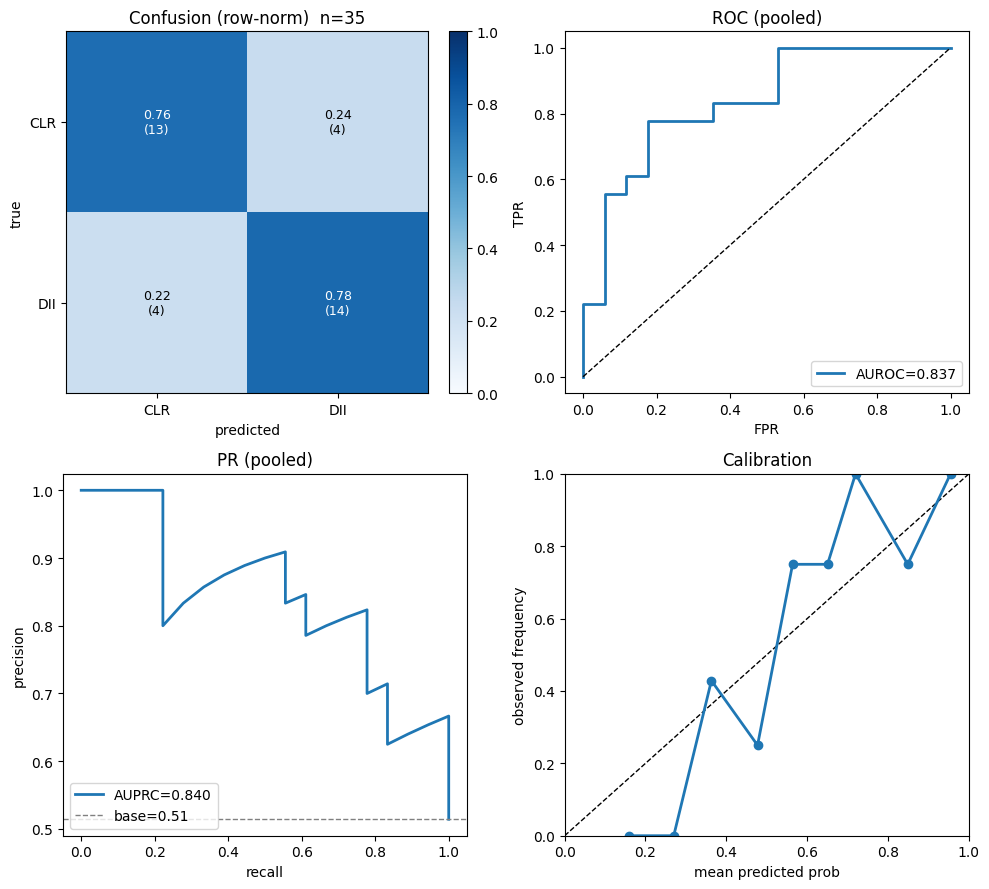

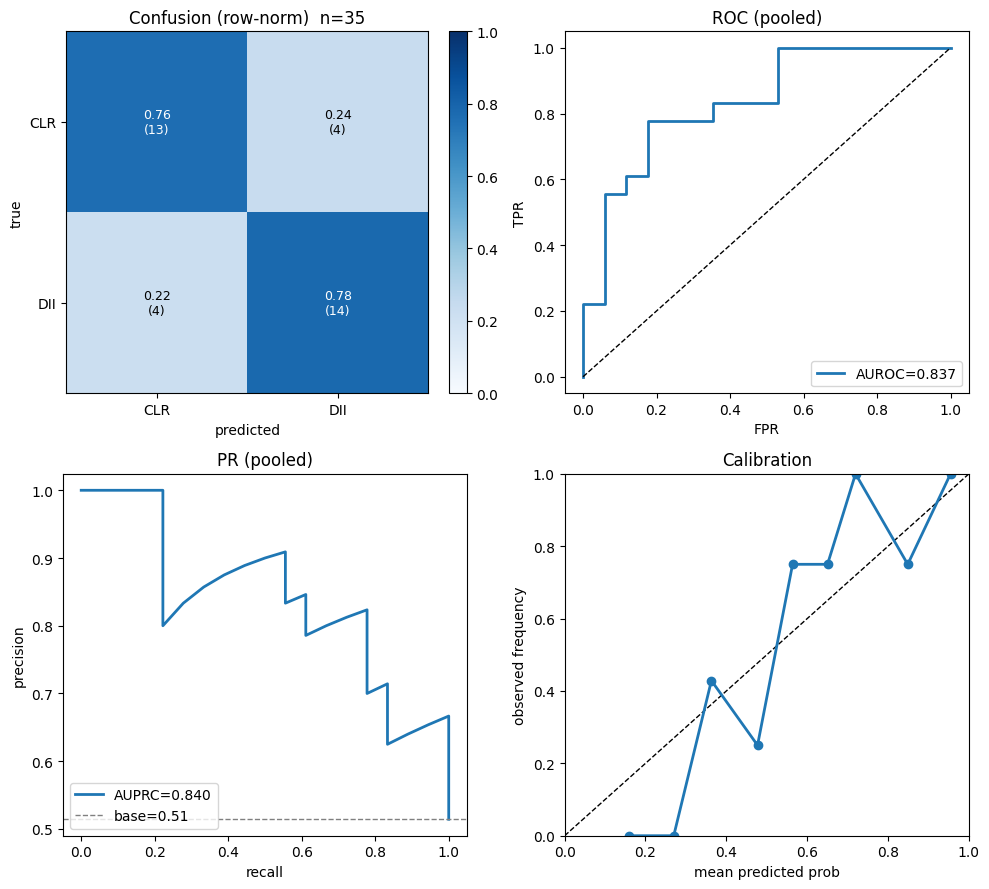

In [11]:
preds = fetch_predictions(group=NESTED_GROUP)
print("raw predictions:", preds.shape, "| unique patients:", preds["patient"].nunique())
print(report(preds, class_names=CLASSES))
prediction_panels(preds, class_names=CLASSES)